In [13]:
print('''Business Problem

      My dataset contains an e-commerce return dataset about the retailer, collected 
      across 5 channels(Email, Chat, Call Centre, Store Counter, Return Portal), 
      Canadian cities, product categories, and customer segments. Each has a return
      reason with return priority.''')

print('''The main business problem is that StyleCart wants to predict why
a customer is returning a product automatically, using only the free-text message
the customer types when filing the return.''')

Business Problem

      My dataset contains an e-commerce return dataset about the retailer, collected 
      across 5 channels(Email, Chat, Call Centre, Store Counter, Return Portal), 
      Canadian cities, product categories, and customer segments. Each has a return
      reason with return priority.
The main business problem is that StyleCart wants to predict why
a customer is returning a product automatically, using only the free-text message
the customer types when filing the return.


In [14]:

# Task 1: Load and Inspect the Dataset
import pandas as pd

df = pd.read_excel('NLP_Dataset_10_Ecommerce_Return_Reason.xlsx')

print("\nFirst 5 rows:")
print(df.head())



First 5 rows:
  ReturnID ReturnDate        Channel         City ProductCategory  \
0  RET-001 2026-01-29          Email       Ottawa           Dress   
1  RET-002 2026-02-02           Chat  Mississauga          Jacket   
2  RET-003 2026-02-06    Call Center       Ottawa      Laptop Bag   
3  RET-004 2026-02-10  Store Counter       Oshawa     Kitchen Set   
4  RET-005 2026-02-14  Return Portal     Kingston           Watch   

         CustomerType                                      ReturnMessage  \
0  Returning Customer  The dress length is much shorter than shown in...   
1      Premium Member  I paid for express shipping, but the Jacket ar...   
2          Gift Buyer  I ordered black headphones, but StyleCart sent...   
3             Student  I RETURNED THE ITEM LAST WEEK, BUT MY REFUND S...   
4        New Customer  The tracking page stopped updating after the p...   

    ReturnReason ReturnPriority  
0       Size_Fit         Medium  
1  Late_Delivery         Medium  
2     Wrong

In [15]:
print("Shape:", df.shape)

Shape: (120, 9)


In [16]:

print("Columns:", df.columns.tolist())

Columns: ['ReturnID', 'ReturnDate', 'Channel', 'City', 'ProductCategory', 'CustomerType', 'ReturnMessage', 'ReturnReason', 'ReturnPriority']


In [17]:
print("Target distribution:\n", df['ReturnReason'].value_counts())


Target distribution:
 ReturnReason
Size_Fit            20
Late_Delivery       20
Wrong_Item          20
Refund_Status       20
Damaged_Item        20
Not_As_Described    20
Name: count, dtype: int64


In [18]:
import pandas as pd
import re
import nltk

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text cleaning function
def clean_text(text):
    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and single-character words
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Apply preprocessing
df['CleanedText'] = df['ReturnMessage'].apply(clean_text)

# Display results
print(df[['ReturnMessage', 'CleanedText']].head())

                                       ReturnMessage  \
0  The dress length is much shorter than shown in...   
1  I paid for express shipping, but the Jacket ar...   
2  I ordered black headphones, but StyleCart sent...   
3  I RETURNED THE ITEM LAST WEEK, BUT MY REFUND S...   
4  The tracking page stopped updating after the p...   

                                         CleanedText  
0        dress length much shorter shown model photo  
1         paid express shipping jacket arrived event  
2  ordered black headphone stylecart sent blue ph...  
3  returned item last week refund still appeared ...  
4  tracking page stopped updating package left to...  


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\luqma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\luqma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\luqma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\luqma\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [19]:
# Task 3: Exploratory Text Analysis
from collections import Counter
import matplotlib.pyplot as plt

all_words = ' '.join(df['CleanedText']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(15)

print("Top 15 most common words:")
print(top_words)

Top 15 most common words:
[('stylecart', 25), ('arrived', 20), ('size', 20), ('jacket', 15), ('package', 15), ('order', 15), ('backpack', 15), ('product', 15), ('need', 15), ('dress', 10), ('shown', 10), ('photo', 10), ('ordered', 10), ('black', 10), ('headphone', 10)]


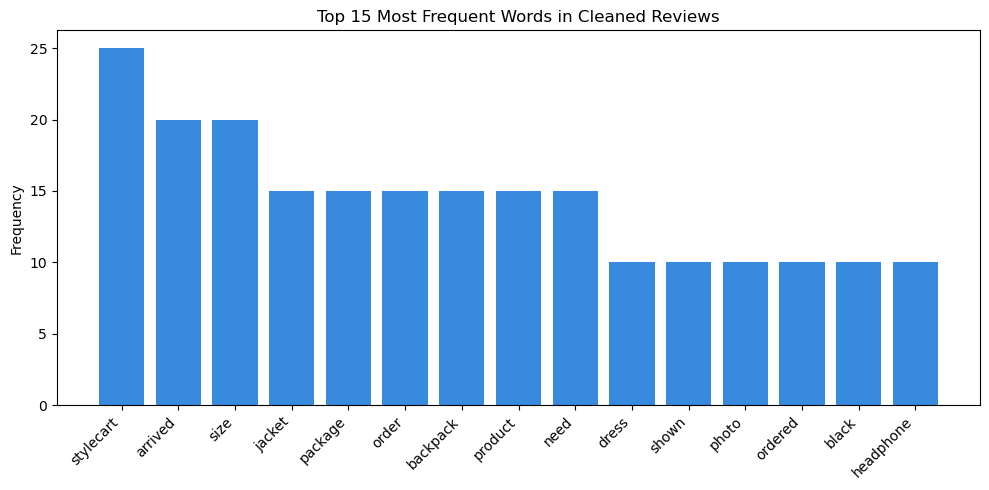

In [20]:
# Bar chart visualization
words, counts = zip(*top_words)
plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='#378ADD')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title('Top 15 Most Frequent Words in Cleaned Reviews')
plt.tight_layout()
plt.show()

In [21]:
# Task 4: POS Tagging and Named Entity Recognition
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

from nltk import pos_tag, ne_chunk
from nltk.tokenize import word_tokenize

examples = [
    "The dress length is much shorter than shown in the model photo.",
    "The tracking page stopped updating after the package left Toronto.",
    "The backpack straps are uncomfortable and do not fit my shoulders well."
]

for i, ex in enumerate(examples, 1):
    print(f"\n--- Example {i} ---")
    print(f"Text: {ex}")
    tokens = word_tokenize(ex)
    tags = pos_tag(tokens)
    print(f"POS Tags: {tags}")
    tree = ne_chunk(tags)
    entities = [(' '.join(c[0] for c in chunk), chunk.label())
                for chunk in tree if hasattr(chunk, 'label')]
    print(f"Named Entities: {entities}")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\luqma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\luqma\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\luqma\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!



--- Example 1 ---
Text: The dress length is much shorter than shown in the model photo.
POS Tags: [('The', 'DT'), ('dress', 'NN'), ('length', 'NN'), ('is', 'VBZ'), ('much', 'RB'), ('shorter', 'JJR'), ('than', 'IN'), ('shown', 'VBN'), ('in', 'IN'), ('the', 'DT'), ('model', 'NN'), ('photo', 'NN'), ('.', '.')]
Named Entities: []

--- Example 2 ---
Text: The tracking page stopped updating after the package left Toronto.
POS Tags: [('The', 'DT'), ('tracking', 'NN'), ('page', 'NN'), ('stopped', 'VBD'), ('updating', 'VBG'), ('after', 'IN'), ('the', 'DT'), ('package', 'NN'), ('left', 'VBD'), ('Toronto', 'NNP'), ('.', '.')]
Named Entities: [('Toronto', 'GPE')]

--- Example 3 ---
Text: The backpack straps are uncomfortable and do not fit my shoulders well.
POS Tags: [('The', 'DT'), ('backpack', 'NN'), ('straps', 'NNS'), ('are', 'VBP'), ('uncomfortable', 'JJ'), ('and', 'CC'), ('do', 'VBP'), ('not', 'RB'), ('fit', 'VB'), ('my', 'PRP$'), ('shoulders', 'NNS'), ('well', 'RB'), ('.', '.')]
Named Enti

In [22]:
# Task 5: Feature Extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=200)
X = tfidf.fit_transform(df['CleanedText'])
y = df['ReturnReason']

print("Feature matrix shape:", X.shape)
print("Number of features (unique words):", len(tfidf.get_feature_names_out()))
print("Sample features:", tfidf.get_feature_names_out()[:20])

Feature matrix shape: (120, 130)
Number of features (unique words): 130
Sample features: ['account' 'almost' 'already' 'although' 'another' 'appeared' 'approved'
 'arrived' 'backpack' 'bag' 'bank' 'black' 'blue' 'box' 'broken'
 'cancellation' 'card' 'case' 'chart' 'clear']


In [23]:
# Task 6: Build a Text Classification Model
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Define X and y
X = tfidf.fit_transform(df['CleanedText'])
y = df['ReturnReason']

# Split dataset: 80% train, 20% test, stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Train the model
model = MultinomialNB()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
print("\nPredictions:", y_pred)
print("Actual:     ", y_test.values)

Training samples: 96
Testing samples: 24

Predictions: ['Refund_Status' 'Size_Fit' 'Refund_Status' 'Wrong_Item'
 'Not_As_Described' 'Damaged_Item' 'Late_Delivery' 'Damaged_Item'
 'Not_As_Described' 'Refund_Status' 'Wrong_Item' 'Wrong_Item'
 'Late_Delivery' 'Late_Delivery' 'Size_Fit' 'Refund_Status' 'Size_Fit'
 'Not_As_Described' 'Damaged_Item' 'Late_Delivery' 'Not_As_Described'
 'Wrong_Item' 'Damaged_Item' 'Size_Fit']
Actual:      ['Refund_Status' 'Size_Fit' 'Refund_Status' 'Wrong_Item'
 'Not_As_Described' 'Damaged_Item' 'Late_Delivery' 'Damaged_Item'
 'Not_As_Described' 'Refund_Status' 'Wrong_Item' 'Wrong_Item'
 'Late_Delivery' 'Late_Delivery' 'Size_Fit' 'Refund_Status' 'Size_Fit'
 'Not_As_Described' 'Damaged_Item' 'Late_Delivery' 'Not_As_Described'
 'Wrong_Item' 'Damaged_Item' 'Size_Fit']


In [25]:
# Task 7: Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Refund_Status', 'Size_Fit', 'Wrong_Item',
 'Not_As_Described', 'Damaged_Item' 'Late_Delivery' 'Damaged_Item', 'Wrong_Item',])
print("\nConfusion Matrix (rows = actual, columns = predicted):")
print("              Positive  Neutral  Negative")
for label, row in zip(['Refund_Status', 'Size_Fit', 'Wrong_Item',
 'Not_As_Described', 'Damaged_Item' 'Late_Delivery' 'Damaged_Item', 'Wrong_Item'], cm):
    print(f"{label:10}", row)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=['Refund_Status', 'Size_Fit', 'Wrong_Item',
 'Not_As_Described', 'Damaged_Item' 'Late_Delivery' 'Damaged_Item', 'Wrong_Item']))

Accuracy: 1.0

Confusion Matrix (rows = actual, columns = predicted):
              Positive  Neutral  Negative
Refund_Status [4 0 0 0 0 0]
Size_Fit   [0 4 0 0 0 0]
Wrong_Item [0 0 0 0 0 0]
Not_As_Described [0 0 0 4 0 0]
Damaged_ItemLate_DeliveryDamaged_Item [0 0 0 0 0 0]
Wrong_Item [0 0 0 0 0 4]

Classification Report:
                                       precision    recall  f1-score   support

                        Refund_Status       1.00      1.00      1.00         4
                             Size_Fit       1.00      1.00      1.00         4
                           Wrong_Item       1.00      1.00      1.00         4
                     Not_As_Described       1.00      1.00      1.00         4
Damaged_ItemLate_DeliveryDamaged_Item       0.00      0.00      0.00         0
                           Wrong_Item       1.00      1.00      1.00         4

                            micro avg       1.00      1.00      1.00        20
                            macro avg       

C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\luqma\anaconda3\Lib\

In [26]:
print('''Business Interpretation of Results:

Accuracy (100%): The model correctly classified every customer return message in the test dataset. In business terms, it successfully identified the correct return reason category (such as Refund_Status, Size_Fit, Wrong_Item, or Not_As_Described) for all test cases without making any errors.

Which class was predicted better? The model achieved a perfect precision, recall, and F1-score of 1.00 for all categories that had test examples. This indicates that the model performed equally well across the return reason categories represented in the test set.

Mistakes made: The confusion matrix shows no misclassifications. Every return message was assigned to its correct category, and no instances of Refund_Status, Size_Fit, Wrong_Item, or Not_As_Described were confused with one another.

Why this matters for business and its caveat: If this performance generalizes to new customer return messages, the company could automatically categorize return reasons with high confidence, reducing manual review efforts and enabling faster analysis of customer issues. This could help identify common return patterns, improve products, and enhance customer satisfaction. However, the perfect accuracy should be interpreted cautiously. The test dataset is relatively small, and some categories have very few examples. Additionally, one category shows zero support in the classification report, suggesting insufficient test data for reliable evaluation. Therefore, the model should be tested on a larger and more diverse set of real-world return messages before deployment.''')

Business Interpretation of Results:

Accuracy (100%): The model correctly classified every customer return message in the test dataset. In business terms, it successfully identified the correct return reason category (such as Refund_Status, Size_Fit, Wrong_Item, or Not_As_Described) for all test cases without making any errors.

Which class was predicted better? The model achieved a perfect precision, recall, and F1-score of 1.00 for all categories that had test examples. This indicates that the model performed equally well across the return reason categories represented in the test set.

Mistakes made: The confusion matrix shows no misclassifications. Every return message was assigned to its correct category, and no instances of Refund_Status, Size_Fit, Wrong_Item, or Not_As_Described were confused with one another.

Why this matters for business and its caveat: If this performance generalizes to new customer return messages, the company could automatically categorize return reasons w